## Gaussian Naive Bayes

## Ví dụ 1

## a. Sử dụng Numpy & Pandas

In [136]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import itertools
from scipy.stats import norm
import scipy.stats
from sklearn.naive_bayes import GaussianNB

- Đọc dữ liệu đầu vào

In [137]:
iris = sns.load_dataset('iris')
iris = iris.rename(index = str, columns = {'sepal_length': '1_sepal_length',
                                           'sepal_width': '2_sepal_width',
                                           'petal_length': '3_petal_length',
                                           'petal_width': '4_petal_width'})
iris

,1_sepal_length,2_sepal_width,3_petal_length,4_petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


- Biểu đồ tán xạ

Text(0.5, 1.0, 'Scatter plot')

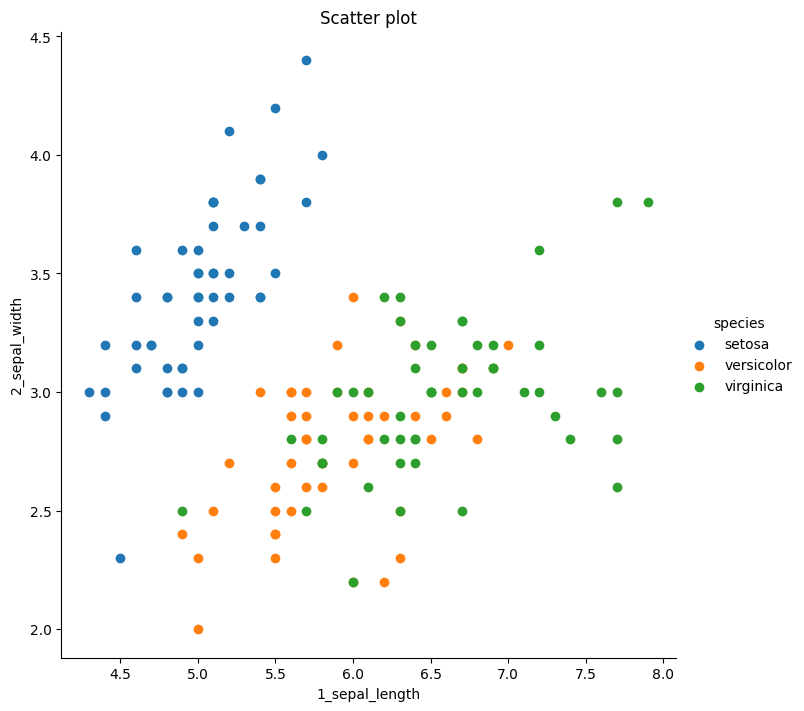

In [138]:
sns.FacetGrid(iris, hue = 'species', height = 7).map(plt.scatter,
                                                   '1_sepal_length',
                                                   '2_sepal_width', ).add_legend()
plt.title('Scatter plot')

- Xây dựng phương pháp Gaussian Naive Bayes dự đoán nhãn của dữ liệu

In [139]:
def predict_NB_gaussian_class(X, mu_list, std_list, pi_list):
    scores_list = []
    classes = len(mu_list)

    for p in range(classes):
        score = (norm.pdf(x = X[0], loc = mu_list[p][0][0], scale = std_list[p][0][0]) * 
                 norm.pdf(x = X[1], loc = mu_list[p][0][1], scale = std_list[p][0][1]) *
                 pi_list[p])
        scores_list.append(score)

    return np.argmax(scores_list)

In [140]:
def predict_Bayes_class(X, mu_list, sigma_list):
    scores_list = []
    classes = len(mu_list)

    for p in range(classes):
        score = scipy.stats.multivariate_normal.pdf(X, 
                                                    mean = mu_list[p], 
                                                    cov = sigma_list[p])
        scores_list.append(score)

    return np.argmax(scores_list)

In [141]:
df1 = iris[['1_sepal_length', '2_sepal_width', 'species']]

- Ước lượng tham số đầu vào (kỳ vọng, độ lệch chuẩn, xác suất tiên nghiệm)

In [142]:
mu_list = np.split(df1.groupby('species').mean().values, [1, 2])

In [143]:
std_list = np.split(df1.groupby('species').std().values, [1, 2], axis = 0)

In [144]:
pi_list = df1.iloc[:, 2].value_counts().values / len(df1)

In [145]:
N = 100
X = np.linspace(4, 8, N)
Y = np.linspace(1.5, 5, N)
X, Y = np.meshgrid(X, Y)

In [146]:
zz = np.array([predict_NB_gaussian_class(np.array([xx, yy]).reshape(-1, 1),
                                         mu_list,
                                         std_list,
                                         pi_list) for xx, yy in zip(np.ravel(X), np.ravel(Y))])
Z = zz.reshape(X.shape)

- Biểu đồ phân lớp sử dụng Gaussian Naive Bayes

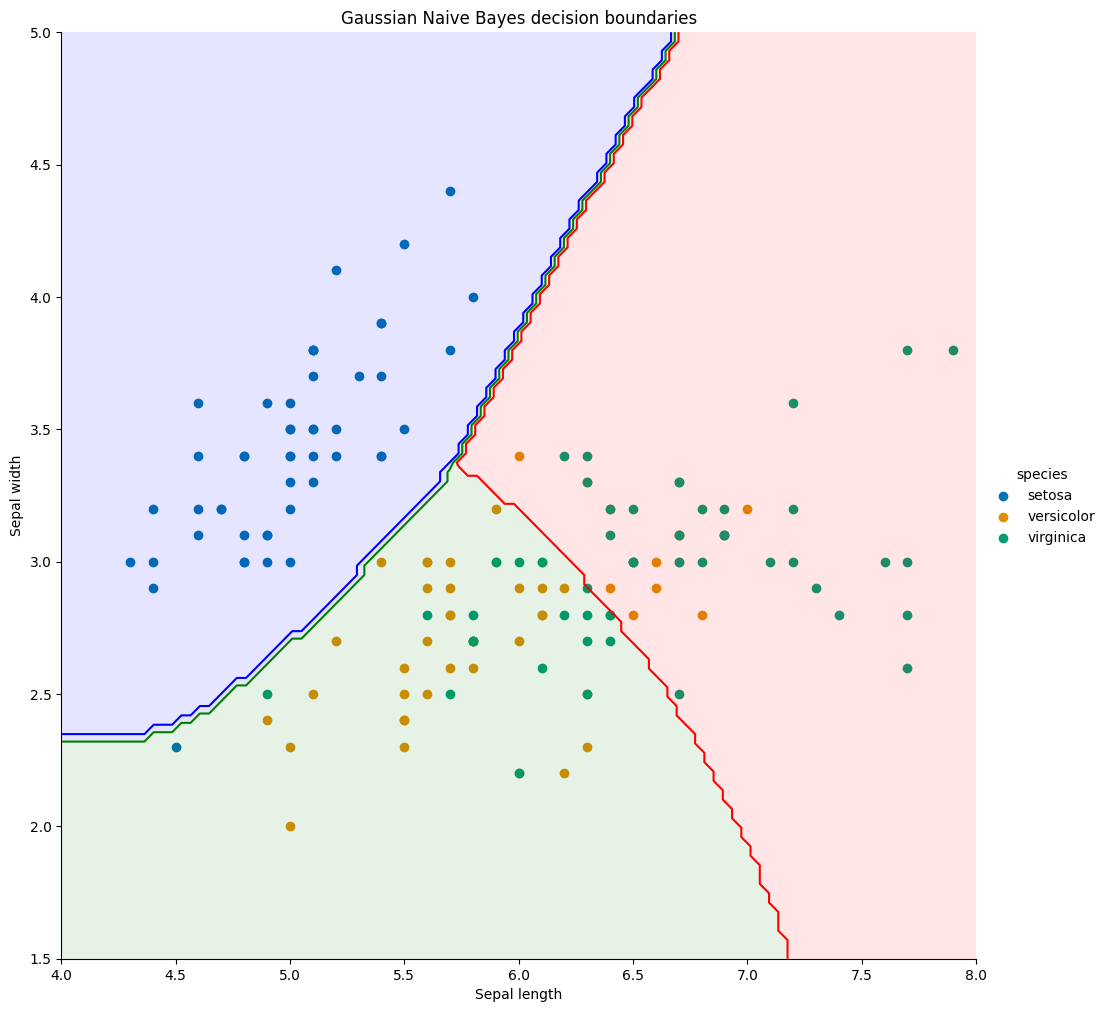

In [147]:
color_list = ['Blues', 'Greens', 'Reds']
my_norm = colors.Normalize(vmin = -1., vmax = 1.)

g = sns.FacetGrid(iris, 
                  hue = 'species', 
                  height = 10, 
                  palette = 'colorblind').map(plt.scatter,
                                              '1_sepal_length',
                                              '2_sepal_width',).add_legend()
my_ax = g.ax

my_ax.contourf(X, Y, Z, 2, alpha = .1, colors = ('blue', 'green', 'red'))
my_ax.contour(X, Y, Z, 2, alpha = 1, colors = ('blue', 'green', 'red'))

my_ax.set_xlabel('Sepal length')
my_ax.set_ylabel('Sepal width')
my_ax.set_title('Gaussian Naive Bayes decision boundaries')

plt.show()

my_ax.set_xlabel('Sepal length')
my_ax.set_ylabel('Sepal width')
my_ax.set_title('Gaussian Naive Bayes decision boundaries')

plt.show()

## b. Sử dụng thư viện Scikit-learn

/tmp/ipykernel_3551/1891205934.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_labels = df1.iloc[:,2].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()
/home/quangvan/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/home/quangvan/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/home/quangvan/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/home/quang

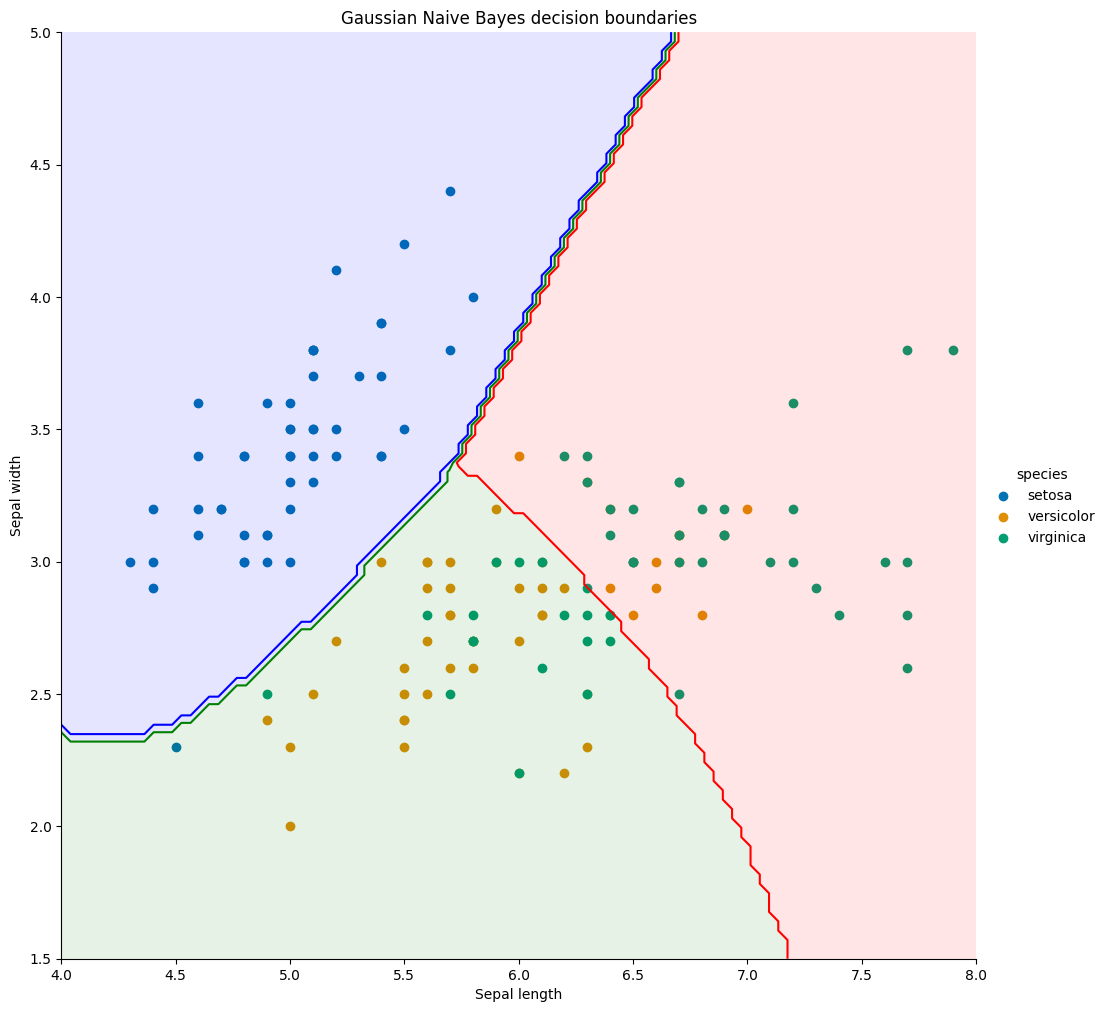

In [148]:
from sklearn.naive_bayes import GaussianNB 
 
#Xây dựng dữ liệu huấn luyện
X_data = df1.iloc[:,0:2] 
y_labels = df1.iloc[:,2].replace({'setosa':0,'versicolor':1,'virginica':2}).copy() 
 
#Mô hình
model_sk = GaussianNB(priors = None) 
model_sk.fit(X_data,y_labels) 
 

N = 100 
X = np.linspace(4, 8, N) 
Y = np.linspace(1.5, 5, N) 
X, Y = np.meshgrid(X, Y) 

color_list = ['Blues','Greens','Reds'] 
my_norm = colors.Normalize(vmin=-1.,vmax=1.) 
 
g = sns.FacetGrid(iris, hue="species", height=10, palette = 'colorblind') .map(plt.scatter, 
"1_sepal_length", "2_sepal_width",)  .add_legend() 
my_ax = g.ax 
 
 
zz = np.array(  [model_sk.predict( [[xx,yy]])[0] for xx, yy in zip(np.ravel(X), np.ravel(Y)
) ] ) 
 

Z = zz.reshape(X.shape) 
 
my_ax.contourf( X, Y, Z, 2, alpha = .1, colors = ('blue','green','red')) 
my_ax.contour( X, Y, Z, 2, alpha = 1, colors = ('blue','green','red')) 
 
# Addd axis and title 
my_ax.set_xlabel('Sepal length') 
my_ax.set_ylabel('Sepal width') 
my_ax.set_title('Gaussian Naive Bayes decision boundaries') 
 
plt.show()

## Ví dụ tự giải

In [1]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score

- Đọc dữ liệu đầu vào

In [5]:
column_names = ['ID', 'Mitoses', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 
                'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Class']
df = pd.read_csv('breast-cancer-wisconsin.data', header = None, names = column_names, na_values="?")
df

,ID,Mitoses,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,2
695,841769,2,1,1,1,2,1.0,1,1,1,2
696,888820,5,10,10,3,7,3.0,8,10,2,4
697,897471,4,8,6,4,3,4.0,10,6,1,4


- Xác định các dòng thiếu dữ liệu

In [4]:
df.isnull().sum()

ID                              0
Mitoses                         0
Clump Thickness                 0
Uniformity of Cell Size         0
Uniformity of Cell Shape        0
Marginal Adhesion               0
Single Epithelial Cell Size    16
Bare Nuclei                     0
Bland Chromatin                 0
Normal Nucleoli                 0
Class                           0
dtype: int64

- Xóa dòng thiếu dữ liệu

In [6]:
df = df.dropna()
df.isnull().sum()

ID                             0
Mitoses                        0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Class                          0
dtype: int64

- Lấy dữ liệu test

In [153]:
benign = df[df['Class'] == 2] #Dữ liệu thuộc nhóm lành tính
malignant = df[df['Class'] == 4] #Dữ liệu thuộc nhóm ác tính

#Chọn 80 mẫu lành tính và 40 mẫu ác tính, xong gộp vào dữ liệu test
test_benign = benign.sample(80, random_state=1)
test_malignant = malignant.sample(40, random_state=1)

test_data = pd.concat([test_benign, test_malignant])

- Lấy dữ liệu training

In [154]:
train_data = df.drop(test_data.index)

- Xây dựng và huấn luyện mô hình

In [155]:
X_train = train_data.drop(['Class','ID'], axis=1) #Input training
y_train = train_data['Class'] #Nhãn huấn luyện

X_test = test_data.drop(['Class','ID'], axis=1) #Input test
y_test = test_data['Class'] #Nhãn thực tế 

model = GaussianNB() #Khởi tạo mô hình
model.fit(X_train, y_train) #Huấn luyện mô hình
y_pred = model.predict(X_test) #Nhãn dự đoán từ mô hình

- Đánh giá mô hình dựa trên accuracy, precision, recall

In [156]:
print('Accuracy Score của mô hình: ', accuracy_score(y_pred, y_test))
print('Precision Score của mô hình: ', precision_score(y_pred, y_test, average = 'macro'))
print('Recall Score của mô hình: ', recall_score(y_pred, y_test, average = 'macro'))

Accuracy Score của mô hình:  0.9583333333333334
Precision Score của mô hình:  0.9624999999999999
Recall Score của mô hình:  0.9469948655995167


## Multinomial Naive Bayes

## Ví dụ 1

In [157]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.naive_bayes import MultinomialNB

- Đọc dữ liệu đầu vào

In [158]:
df = pd.read_csv('multinomial_nb_orders.csv')
df.head()

,cuisine,city,device,user_segment,promo,fav_ingredient,spice_level,day_of_week,price_bucket
0,american,city_16,web,new,promo_1,onion,hot,Wed,high
1,thai,city_10,ios,family,promo_7,cilantro,mild,Wed,mid
2,american,city_18,ios,student,promo_1,cheese,hot,Fri,mid
3,japanese,city_10,web,family,promo_3,ginger,mild,Tue,high
4,vietnamese,city_10,web,family,none,fish_sauce,mild,Wed,low


- Tính xác suất tiên nghiệm của mỗi lớp

In [159]:
target_feature = 'cuisine'

Y = df[target_feature]
labels = np.zeros((len(set(Y)), 2), dtype = Y.dtype)

id = 0
for label in set(Y):
    labels[id, 0] = label
    labels[id, 1] = (Y == label).sum() / len(Y)
    id += 1
labels

array([['mediterranean', np.float64(0.082)],
       ['american', np.float64(0.13466666666666666)],
       ['mexican', np.float64(0.102)],
       ['thai', np.float64(0.10333333333333333)],
       ['vietnamese', np.float64(0.09933333333333333)],
       ['korean', np.float64(0.065)],
       ['chinese', np.float64(0.12366666666666666)],
       ['indian', np.float64(0.09333333333333334)],
       ['japanese', np.float64(0.10133333333333333)],
       ['italian', np.float64(0.09533333333333334)]], dtype=object)

- Xác định số lựa chọn tối đa của mỗi trường

In [160]:
def get_distinct_value_in_fields():    
    array = []
    for col in df.columns:
        array.append([col, int(df[col].nunique())])
    return np.array(array, dtype = object)

- Tính P(x_i | k)

In [161]:
def Pxik_feature_in_class(X, xi, num_nomials_M, alpha = 1.0):
    X = np.array(X)
    count = (X == xi).sum()
    return (count + alpha) / (len(X) + num_nomials_M * alpha)

- Dự đoán nhãn đầu ra cho tập dữ liệu test

In [162]:
def predict_output_label(X, x_input, p_labels, target_feature):
    num_labels_M = get_distinct_value_in_fields()
    p = np.log(np.array(p_labels[:, 1], dtype = float))

    for k in range(len(p)):
        X_k = X[X[target_feature] == p_labels[k, 0]]
        for i in range(len(x_input)):
            p[k] += np.log(Pxik_feature_in_class(X_k.iloc[:, i + 1],
                                                 x_input.iloc[i],
                                                 num_labels_M[i + 1, 1]))
    y_star = np.argmax(p)
    return p_labels[y_star, 0]

- Chia tập dữ liệu thành tập training và tập test, dự đoán nhãn đầu ra cho tập dữ liệu test

In [163]:
train_size = round(len(df) * 0.7)
X_train = df[:train_size]
Y_train = df[target_feature][:train_size]

X_test = df[train_size:].drop(target_feature,
                               axis = 1).reset_index(drop = True,
                                                     inplace = False)
Y_test = df[target_feature][train_size:].reset_index(drop = True,
                                                     inplace = False)

Y_pred = np.zeros(len(Y_test), dtype = Y_test.dtype)

print(len(X_test), len(Y_test))
print(X_test.index, Y_test.index)

for i in range(len(X_test)):
    Y_pred[i] = predict_output_label(X_train, X_test.iloc[i, :],
                                     labels, target_feature)

900 900
RangeIndex(start=0, stop=900, step=1) RangeIndex(start=0, stop=900, step=1)


- Đánh giá mô hình dựa trên accuracy, precision, recall

In [164]:
print(accuracy_score(Y_pred, Y_test))
print(precision_score(Y_pred, Y_test, average = 'macro'))
print(recall_score(Y_pred, Y_test, average = 'macro'))
print(predict_output_label(X_train, X_train.iloc[3, 1:], labels, target_feature)) 

0.49
0.465216691060228
0.46913157260926547
chinese


*) Sử dụng thư viện Scikit-learn

- Đánh số cho giá trị trên tập dữ liệu training & test

In [165]:
X_all = pd.concat([X_train, X_test])

X_all_enc = pd.get_dummies(X_all)

X_train_enc = X_all_enc.iloc[:len(X_train)]
X_test_enc  = X_all_enc.iloc[len(X_train):]

- Xây dựng mô hình và đánh giá mô hình dựa trên accuracy, precision, recall

In [166]:
model = MultinomialNB(alpha = 1)
model.fit(X_train_enc, Y_train)

Y_pred = model.predict(X_test_enc)
print('Accuracy: ', accuracy_score(Y_pred, Y_test))
print('Precision: ', precision_score(Y_pred, Y_test, average = 'macro'))
print('Recall: ', recall_score(Y_pred, Y_test, average = 'macro'))

Accuracy:  0.4866666666666667
Precision:  0.4643315266972542
Recall:  0.4681368355151722


## Bernoulli Naive Bayes

## Ví dụ 2

In [167]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [168]:
symptoms_data = []

with open ('bernoulli_nb_symptoms.csv') as f:
    lines = f.readlines()

for line in lines:
    x = line.strip().split(',')
    symptoms_data.append(x)

df = pd.DataFrame(symptoms_data)
df.columns = df.iloc[0]
df = df.drop(0)
df = df.reset_index(drop = True)
df.index = df.index + 1
df.head()

,condition,fever,chills,runny_nose,sneezing,cough,sore_throat,headache,nausea,vomiting,...,dehydration_signs,dry_mouth,dark_urine,rapid_heart_rate,sweating,itchy_eyes,watery_eyes,nasal_congestion,postnasal_drip,joint_pain
1,food_poison,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,flu,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,flu,0,0,0,0,1,0,0,0,0,...,0,1,0,1,0,0,0,1,0,1
4,stomach_bug,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,food_poison,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [169]:
train_data = df.iloc[:1500, 1:]
train_label = df.iloc[:1500, 0]

test_data = df.iloc[1500:, 1:]
test_label = df.iloc[1500:, 0]

model = BernoulliNB(alpha = 1)
model.fit(train_data, train_label)

y_pred = model.predict(test_data)

print('Accuracy Score của mô hình: ', accuracy_score(test_label, y_pred))
print('Precision Score của mô hình: ', precision_score(test_label, y_pred, average = 'macro'))
print('Recall Score của mô hình: ', recall_score(test_label, y_pred, average = 'macro'))
print('Confusion Matrix của mô hình: ')
print(confusion_matrix(test_label, y_pred))
print(Y_pred[3])

Accuracy Score của mô hình:  0.485
Precision Score của mô hình:  0.48711119643463596
Recall Score của mô hình:  0.478423928469073
Confusion Matrix của mô hình: 
[[47 30  8  1 12  4  5  2]
 [12 90 13 13 12  6 11  2]
 [11 11 73  8 21 12  4  7]
 [ 4 12  3 52 10  8  3  4]
 [ 9 20 22  3 83  9 13  4]
 [ 3 11 11  1  5 50  8 22]
 [11 13  7  6  5  4 34  4]
 [ 6 14  4  4 12 26  9 56]]
american


## Bài tập 2

In [170]:
target_feature = 'condition'

Y = df[target_feature]
labels = np.zeros((len(set(Y)), 2), dtype = Y.dtype)

id = 0
for label in set(Y):
    labels[id, 0] = label
    labels[id, 1] = (Y == label).sum() / len(Y)
    id += 1
labels

array([['migraine', np.float64(0.0936)],
       ['food_poison', np.float64(0.1064)],
       ['flu', np.float64(0.1532)],
       ['stomach_bug', np.float64(0.1236)],
       ['cold', np.float64(0.1576)],
       ['allergy', np.float64(0.1184)],
       ['dehydration', np.float64(0.094)],
       ['covid_like', np.float64(0.1532)]], dtype=object)

In [171]:
def Pxik_feature_in_class(X, x_i, alpha = 1.0):
    X = np.array(X)
    count = (X == x_i).sum()
    return (count + alpha) / (len(X) + 2 * alpha)

In [172]:
def predict_output_label(X, x_input, p_labels, target_feature):
    p = np.log(np.array(p_labels[:, 1], dtype = float))

    for k in range(len(p)):
        X_k = X[X[target_feature] == p_labels[k, 0]]
        for i in range(len(x_input)):
            p[k] += np.log(Pxik_feature_in_class(X_k.iloc[:, i + 1],
                                                 x_input.iloc[i]))
    y_star = np.argmax(p)
    return p_labels[y_star, 0]

In [173]:
train_size = round(len(df) * 0.6)
X_train = df[:train_size]
Y_train = df[target_feature][:train_size]

X_test = df[train_size:].drop(target_feature,
                               axis = 1).reset_index(drop = True,
                                                     inplace = False)
Y_test = df[target_feature][train_size:].reset_index(drop = True,
                                                     inplace = False)

Y_pred = np.zeros(len(Y_test), dtype = Y_test.dtype)

for i in range(len(X_test)):
    Y_pred[i] = predict_output_label(X_train, X_test.iloc[i, :],
                                     labels, target_feature)

In [174]:
print('Accuracy Score của mô hình: ', accuracy_score(Y_pred, test_label))
print('Precision Score của mô hình: ', precision_score(Y_pred, test_label, average = 'macro'))
print('Recall Score của mô hình: ', recall_score(Y_pred, test_label, average = 'macro'))
print(predict_output_label(X_train, X_test.iloc[3], labels, target_feature))

Accuracy Score của mô hình:  0.49
Precision Score của mô hình:  0.4830164759414439
Recall Score của mô hình:  0.49340257434870777
stomach_bug


## Bài tập
- Đầu ra cần dự đoán ở trong trường damage_grade, được chia làm 03 mức 1, 2, 3 tương ứng với
mức độ thiệt hại của tòa nhà: Thiệt hại nhẹ, trung bình, phá hủy hoàn toàn. Mặc dù đầu ra có tính thứ tự,
tuy nhiên trong bài tập này chúng ta coi các giá trị này hoàn toàn chỉ mang tính phân loại.

In [175]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split

In [176]:
train_values = pd.read_csv('train_values.csv')
train_labels = pd.read_csv('train_labels.csv')
test_values = pd.read_csv('test_values.csv')

## Bài 1

In [177]:
categorical_cols = [
    'land_surface_condition',
    'foundation_type',
    'roof_type',
    'ground_floor_type',
    'other_floor_type',
    'position',
    'plan_configuration',
    'legal_ownership_status'
]

X = pd.get_dummies(train_values[categorical_cols])
y = train_labels['damage_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [178]:
model = MultinomialNB(alpha = 1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [179]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))

Accuracy: 0.5664703286583143
Precision: 0.5166613258119347
Recall: 0.4634058259825678


## Bài 2

In [180]:
categorical_cols = [
    'has_superstructure_adobe_mud',
    'has_superstructure_mud_mortar_stone',
    'has_superstructure_stone_flag',
    'has_superstructure_cement_mortar_stone',
    'has_superstructure_mud_mortar_brick',
    'has_superstructure_cement_mortar_brick',
    'has_superstructure_timber',
    'has_superstructure_bamboo',
    'has_superstructure_rc_non_engineered',
    'has_superstructure_rc_engineered',
    'has_superstructure_other',
    'has_secondary_use',
    'has_secondary_use_agriculture',
    'has_secondary_use_hotel',
    'has_secondary_use_rental',
    'has_secondary_use_institution',
    'has_secondary_use_school',
    'has_secondary_use_industry',
    'has_secondary_use_health_post',
    'has_secondary_use_gov_office',
    'has_secondary_use_use_police',
    'has_secondary_use_other'
]

X = pd.get_dummies(train_values[categorical_cols])
y = train_labels['damage_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [181]:
model = BernoulliNB(alpha = 1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [182]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average = 'macro'))
print("Recall:", recall_score(y_test, y_pred, average = 'macro'))

Accuracy: 0.5650313693137123
Precision: 0.521478102296685
Recall: 0.45954092880055786


## Phương pháp Naive Bayes cho phân loại văn bản

## Ví dụ 2

* Sử dụng Multinomial Naive Bayes

In [183]:
from __future__ import print_function
from sklearn.naive_bayes import MultinomialNB
import numpy as np

In [184]:
d1 = [2, 1, 1, 0, 0, 0, 0, 0, 0]
d2 = [1, 1, 0, 1, 1, 0, 0, 0, 0]
d3 = [0, 1, 0, 0, 1, 1, 0, 0, 0]
d4 = [0, 1, 0, 0, 0, 0, 1, 1, 1]

train_data = np.array([d1, d2, d3, d4])
label = np.array(['B', 'B', 'B', 'N'])

d5 = np.array([[2, 0, 0, 1, 0, 0, 0, 1, 0]])
d6 = np.array([[0, 1, 0, 0, 0, 0, 0, 1, 1]])

In [185]:
clf = MultinomialNB(alpha = 1)
clf.fit(train_data, label)

,alpha,1
,force_alpha,True
,fit_prior,True
,class_prior,None


In [186]:
print('Predicting class of d5:', str(clf.predict(d5)[0]))
print('Predicting class of d6:', str(clf.predict(d6)[0]))
print('Probability of d5 in each class:', clf.predict_proba(d5))
print('Probability of d6 in each class:', clf.predict_proba(d6))

Predicting class of d5: B
Predicting class of d6: N
Probability of d5 in each class: [[0.89548823 0.10451177]]
Probability of d6 in each class: [[0.29175335 0.70824665]]


- Do P(B | d5) > P(N | d5) nên ta dự đoán d5 thuộc lớp B
- Do P(B | d6) < P(N | d6) nên ta dự đoán d6 thuộc lớp N

* Sử dụng Bernoulli Naive Bayes

In [187]:
from __future__ import print_function
from sklearn.naive_bayes import BernoulliNB
import numpy as np

In [188]:
d1 = [1, 1, 1, 0, 0, 0, 0, 0, 0]
d2 = [1, 1, 0, 1, 1, 0, 0, 0, 0]
d3 = [0, 1, 0, 0, 1, 1, 0, 0, 0]
d4 = [0, 1, 0, 0, 0, 0, 1, 1, 1]

train_data = np.array([d1, d2, d3, d4])
labels = np.array(['B', 'B', 'B', 'N'])

d5 = np.array([[1, 0, 0, 1, 0, 0, 0, 1, 0]])
d6 = np.array([[0, 1, 0, 0, 0, 0, 0, 1, 1]])

In [189]:
model = BernoulliNB(alpha = 1)
model.fit(train_data, labels)

,alpha,1
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [190]:
print('Predicting class of d5:', str(model.predict(d5)[0]))
print('Predicting class of d6:', str(model.predict(d6)[0]))
print('Probability of d5 in each class:', model.predict_proba(d5))
print('Probability of d6 in each class:', model.predict_proba(d6))

Predicting class of d5: B
Predicting class of d6: N
Probability of d5 in each class: [[0.76554295 0.23445705]]
Probability of d6 in each class: [[0.16948581 0.83051419]]


- Do P(B | d5) > P(N | d5) nên ta dự đoán d5 thuộc lớp B
- Do P(B | d6) < P(N | d6) nên ta dự đoán d6 thuộc lớp N

## Ví dụ 3

In [191]:
from __future__ import division, print_function, unicode_literals
import numpy as np
from scipy.sparse import coo_matrix
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [192]:
path = 'ex6DataPrepared/'
train_data_fn = 'train-features.txt'
test_data_fn = 'test-features.txt'

train_label_fn = 'train-labels.txt'
test_label_fn = 'test-labels.txt'

In [193]:
nwords = 2500
def read_data(data_fn, label_fn):
    with open(path + label_fn) as f: 
        content = f.readlines() 
    label = [int(x.strip()) for x in content] 

    with open(path + data_fn) as f: 
        content = f.readlines() 

    content = [x.strip() for x in content]  
 
    dat = np.zeros((len(content), 3), dtype = int) 
     
    for i, line in enumerate(content):  
        a = line.split(' ') 
        dat[i, :] = np.array([int(a[0]), int(a[1]), int(a[2])]) 
     

    data = coo_matrix((dat[:, 2], (dat[:, 0] - 1, dat[:, 1] - 1)),
             shape=(len(label), nwords)) 
    return (data, label)

In [194]:
(train_data, train_label)  = read_data(train_data_fn, train_label_fn) 
(test_data, test_label)  = read_data(test_data_fn, test_label_fn) 
 
clf = MultinomialNB() 
clf.fit(train_data, train_label) 
y_pred = clf.predict(test_data) 

In [195]:
print('Accuracy Score của mô hình: ', accuracy_score(y_pred, test_label))
print('Precision Score của mô hình: ', precision_score(y_pred, test_label, average = 'macro'))
print('Recall Score của mô hình: ', recall_score(y_pred, test_label, average = 'macro'))

Accuracy Score của mô hình:  0.9807692307692307
Precision Score của mô hình:  0.9807692307692308
Recall Score của mô hình:  0.9810253981410219
